In [1]:
!pip install -q datasets torchvision tqdm|

/bin/bash: -c: line 2: syntax error: unexpected end of file


In [2]:
import os
import torch
from torchvision import transforms
from PIL import Image
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# 1. Define Standard Preprocessing Transformations
# For style transfer, we typically resize and center-crop to a uniform square (e.g., 256x256 or 512x512)
IMAGE_SIZE = 256
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    # VGG networks expect inputs normalized this way if you're using pre-trained weights
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Custom PyTorch Dataset wrapper for Hugging Face image streams
class StyleTransferDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        # 1. Try the standard 'image' key first
        if 'image' in item:
            img = item['image']
        # 2. Fallback: Dynamically find the column containing the PIL Image object
        else:
            img = next((val for val in item.values() if isinstance(val, Image.Image)), None)

            # 3. Last resort fallback if type checking fails
            if img is None:
                raise KeyError(f"Could not find an image column. Available keys: {list(item.keys())}")

        # Ensure it's in RGB mode (drops alpha channels or grayscale conflicts)
        img = img.convert('RGB')

        if self.transform:
            img = self.transform(img)
        return img
print("⏳ Streaming a tiny slice of MS-COCO for Content Images...")
# Using a stable, true-image Parquet COCO repo
coco_stream = load_dataset("DavidPhilips/coco2017", split="validation", streaming=True)
coco_raw = list(coco_stream.take(500))
content_dataset = StyleTransferDataset(coco_raw, transform=transform)
print(f"✓ Loaded {len(content_dataset)} Content Images.")

print("\n⏳ Streaming a tiny slice of Artworks for Style Images...")
# Wikiart supports native image data streaming perfectly
style_stream = load_dataset("huggan/wikiart", split="train", streaming=True)
style_raw = list(style_stream.take(200))
style_dataset = StyleTransferDataset(style_raw, transform=transform)
print(f"✓ Loaded {len(style_dataset)} Style Images.")

⏳ Streaming a tiny slice of MS-COCO for Content Images...


Resolving data files:   0%|          | 0/96 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/96 [00:00<?, ?it/s]

✓ Loaded 500 Content Images.

⏳ Streaming a tiny slice of Artworks for Style Images...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

✓ Loaded 200 Style Images.


In [3]:
"""
Neural Style Transfer (Gatys et al., 2016)
"Image Style Transfer Using Convolutional Neural Networks"

No training dataset is required. VGG-19 (pretrained on ImageNet) is used purely
as a FROZEN feature extractor. The optimized variable is the output image's
PIXELS themselves, optimized per (content, style) pair via gradient descent
(L-BFGS), not any network weights.

Usage:
    python gatys_style_transfer.py --content content.jpg --style style.jpg \
        --output output.png --steps 300 --style-weight 1e6 --content-weight 1

Requires: torch, torchvision, pillow
"""

import argparse
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import models, transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ImageNet normalization stats VGG was trained with -- required since we're
# using VGG's frozen, pretrained weights as-is.
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

# Layers used for content / style losses, following the paper.
# Names follow the standard VGG19 conv-block numbering.
CONTENT_LAYERS = ["conv5_2"]
STYLE_LAYERS = ["conv1_1", "conv2_1", "conv3_1", "conv4_1", "conv5_1"]

# Per-style-layer weights (paper uses equal weighting w_l = 1/len(style_layers))
# essentially the W_l in style loss
STYLE_LAYER_WEIGHTS = {name: 1.0 / len(STYLE_LAYERS) for name in STYLE_LAYERS}

VGG19_LAYER_NAMES = [
    "conv1_1", "relu1_1", "conv1_2", "relu1_2", "pool1",
    "conv2_1", "relu2_1", "conv2_2", "relu2_2", "pool2",
    "conv3_1", "relu3_1", "conv3_2", "relu3_2", "conv3_3", "relu3_3", "conv3_4", "relu3_4", "pool3",
    "conv4_1", "relu4_1", "conv4_2", "relu4_2", "conv4_3", "relu4_3", "conv4_4", "relu4_4", "pool4",
    "conv5_1", "relu5_1", "conv5_2", "relu5_2", "conv5_3", "relu5_3", "conv5_4", "relu5_4", "pool5",
]


def build_vgg_feature_extractor():
    """
    Load VGG-19 pretrained on ImageNet, freeze all weights, and replace
    max-pooling with average-pooling. Gatys et al. report that average
    pooling gives smoother gradients / visually cleaner results than max
    pooling for this optimization task; the network is used purely as a
    fixed measuring instrument either way, no weights are ever updated.
    """
    vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
    vgg = vgg.to(DEVICE).eval()

    for param in vgg.parameters():
        param.requires_grad_(False)  # frozen: never updated during optimization

    named_layers = nn.ModuleList()
    for name, layer in zip(VGG19_LAYER_NAMES, vgg.children()):
        if isinstance(layer, nn.MaxPool2d):
            layer = nn.AvgPool2d(kernel_size=2, stride=2)
        named_layers.append(layer)

    return named_layers # which is a list of all the layers in vgg after replacing all maxpool with avgpool.


def extract_features(image, vgg_layers, layers_wanted):
    """
    Run `image` through the VGG feature extractor, returning a dict of
    {layer_name: activation_tensor} for every layer in `layers_wanted`.
    Equivalent to phi_l(image) for each requested l, computed in ONE
    forward pass (later layers reuse earlier layers' activations).
    """
    features = {}
    x = image
    for name, layer in zip(VGG19_LAYER_NAMES, vgg_layers):
        x = layer(x)
        if name in layers_wanted:
            features[name] = x
        if len(features) == len(layers_wanted):
            break
    return features


def gram_matrix(feat):
    """
    G_ij = sum_k F_ik * F_jk, normalized by number of elements.
    feat: (1, C, H, W) -> returns (C, C) Gram matrix.
    """
    batch_size, c, h, w = feat.shape
    f = feat.view(c, h * w)
    g = f @ f.t()
    return g / (c * h * w)  # normalization keeps loss scale independent of feature map size


def load_image(path, max_size=512):
    image = Image.open(path).convert("RGB")
    scale = max_size / max(image.size)
    if scale < 1.0:
        new_size = (int(image.size[0] * scale), int(image.size[1] * scale))
        image = image.resize(new_size, Image.LANCZOS)
    tensor = transforms.ToTensor()(image).unsqueeze(0)  # (1, 3, H, W), range [0, 1]
    return tensor.to(DEVICE)


def normalize_for_vgg(image):
    """VGG expects ImageNet-normalized input; our optimized pixels stay in [0,1]."""
    return (image - IMAGENET_MEAN.to(DEVICE)) / IMAGENET_STD.to(DEVICE)


def save_image(tensor, path):
    image = tensor.detach().clamp(0, 1).cpu().squeeze(0)
    transforms.ToPILImage()(image).save(path)




In [4]:
import matplotlib.pyplot as plt

def show_image(tensor, title="Stylized Image"):
    """Clamps, converts a PyTorch tensor to a PIL Image, and prints it on screen."""
    # Remove batch dim, clamp to valid [0, 1] range, and move to CPU
    image = tensor.detach().clamp(0, 1).cpu().squeeze(0)
    # Convert from (C, H, W) to (H, W, C) for matplotlib
    image = image.permute(1, 2, 0).numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(title)
    plt.show()

In [25]:
def run_style_transfer(
    content_idx, # Added content index parameter
    style_idx,   # Added style index parameter
    steps=500,
    content_weight=10,      # Restored to standard baseline
    style_weight=1e4,        # Scaled down because weights aren't fighting normalization
    init_from_content=True,
):
    vgg_layers = build_vgg_feature_extractor()

    # Use the provided indices to get content and style images
    style_img_tensor = style_dataset[style_idx].unsqueeze(0).to(DEVICE)
    content_img_tensor = content_dataset[content_idx].unsqueeze(0).to(DEVICE)

    # Ensure style image is resized to match content image dimensions
    style_img_tensor = F.interpolate(style_img_tensor, size=content_img_tensor.shape[-2:], mode="bilinear", align_corners=False)

    # Removed show_image calls from here, as the combined function will handle display
    # show_image(style_img_tensor, title="style image")
    # show_image(content_img_tensor, title="content image")

    all_layers = set(CONTENT_LAYERS) | set(STYLE_LAYERS)

    # 1. Pre-normalize targets immediately so everything resides in VGG space
    with torch.no_grad():
        norm_content = normalize_for_vgg(content_img_tensor)
        norm_style = normalize_for_vgg(style_img_tensor)

        content_targets = extract_features(norm_content, vgg_layers, all_layers)
        style_targets = extract_features(norm_style, vgg_layers, all_layers)

        style_grams = {name: gram_matrix(style_targets[name]) for name in STYLE_LAYERS}
        content_targets = {name: content_targets[name] for name in CONTENT_LAYERS}

    # 2. Initialize the optimization variable ALREADY NORMALIZED
    if init_from_content:
        output_img = norm_content.clone()
    else:
        output_img = normalize_for_vgg(torch.rand_like(content_img_tensor))

    output_img = output_img.to(DEVICE).requires_grad_(True)

    # L-BFGS works smoothly here because gradients map 1:1 with the loss scale
    optimizer = torch.optim.LBFGS([output_img], max_iter=steps, line_search_fn="strong_wolfe")

    step_count = [0]

    def closure():
        optimizer.zero_grad()

        # 3. No clamping or normalization here! output_img is optimized directly in VGG space
        feats = extract_features(output_img, vgg_layers, all_layers)

        content_loss = sum(
            F.mse_loss(feats[name], content_targets[name]) for name in CONTENT_LAYERS
        )
        style_loss = sum(
            STYLE_LAYER_WEIGHTS[name] * F.mse_loss(gram_matrix(feats[name]), style_grams[name])
            for name in STYLE_LAYERS
        )

        total_loss = content_weight * content_loss + style_weight * style_loss
        total_loss.backward()

        step_count[0] += 1
        if step_count[0] % 100 == 0 or step_count[0] == 1: # Reduced print frequency
            print(
                f"step {step_count[0]:4d} | total {total_loss.item():.2f} "
                f"| content {content_loss.item():.4f} | style {style_loss.item():.6f}"
            )
        return total_loss

    optimizer.step(closure)

    # 4. Denormalize the optimized VGG tensor back to standard [0, 1] range for visualization
    final_img_tensor = output_img.detach() * IMAGENET_STD.to(DEVICE) + IMAGENET_MEAN.to(DEVICE)
    final_img_tensor = final_img_tensor.clamp(0, 1)

    # Removed show_image call here
    # show_image(final_img_tensor, title="Final Stylized Output")

    return content_img_tensor, style_img_tensor, final_img_tensor # Return all three image tensors

In [26]:
# Removed direct call to run_style_transfer here, it will be called by the new function.


Running style transfer for content index 7 and style index 8...
step    1 | total 85.30 | content 0.0000 | style 0.008530
step  100 | total 0.73 | content 0.0416 | style 0.000032
step  200 | total 0.42 | content 0.0242 | style 0.000018
step  300 | total 0.34 | content 0.0190 | style 0.000015
step  400 | total 0.30 | content 0.0165 | style 0.000013
step  500 | total 0.27 | content 0.0151 | style 0.000012
Could not load 'arial.ttf', using default font.
Combined image saved as example_combined_output.png


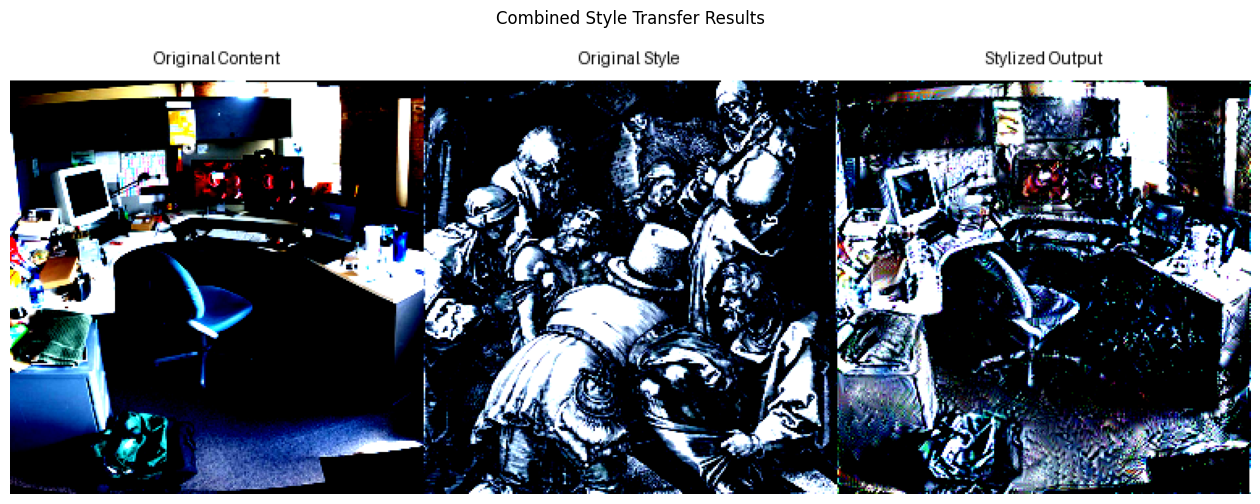

In [30]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def tensor_to_pil(tensor):
    """Converts a PyTorch tensor (C, H, W, range [0, 1]) to a PIL Image."""
    # Remove batch dimension, clamp to valid [0, 1] range, and move to CPU
    image = tensor.detach().clamp(0, 1).cpu().squeeze(0)
    # Convert from (C, H, W) to (H, W, C) for PIL
    return transforms.ToPILImage()(image)

def download_combined_images(content_idx, style_idx, output_filename="combined_style_transfer.png"):
    """
    Performs style transfer for given content and style indices,
    then combines the original content, original style, and stylized images
    into a single image with labels, and saves/displays it.

    Args:
        content_idx (int): Index of the content image from content_dataset.
        style_idx (int): Index of the style image from style_dataset.
        output_filename (str): Name of the file to save the combined image.
    """
    print(f"\nRunning style transfer for content index {content_idx} and style index {style_idx}...")
    content_tensor, style_tensor, stylized_tensor = run_style_transfer(
        content_idx=content_idx, style_idx=style_idx
    )

    # Convert tensors to PIL Images
    content_pil = tensor_to_pil(content_tensor)
    style_pil = tensor_to_pil(style_tensor)
    stylized_pil = tensor_to_pil(stylized_tensor)

    # Get image dimensions (they should all be the same, e.g., IMAGE_SIZE x IMAGE_SIZE)
    width, height = content_pil.size

    # Define spacing and text height for labels
    label_height = 30 # pixels for text label
    total_height = height + label_height
    combined_width = width * 3

    # Create a new blank image with white background
    combined_image = Image.new('RGB', (combined_width, total_height), color=(255, 255, 255))
    draw = ImageDraw.Draw(combined_image)

    # Try to load a default font, fall back if not found
    try:
        font = ImageFont.truetype("arial.ttf", 20)
    except IOError:
        font = ImageFont.load_default()
        print("Could not load 'arial.ttf', using default font.")

    # Paste images and add labels
    images_to_combine = [
        (content_pil, "Original Content"),
        (style_pil, "Original Style"),
        (stylized_pil, "Stylized Output")
    ]

    for i, (img, label) in enumerate(images_to_combine):
        x_offset = i * width
        y_offset = label_height # Leave space at the top for the label

        # Paste the image
        combined_image.paste(img, (x_offset, y_offset))

        # Add the label centered above the image
        # Use textbbox instead of textsize for newer Pillow versions
        bbox = draw.textbbox((0, 0), label, font=font)
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]

        text_x = x_offset + (width - text_width) // 2
        text_y = (label_height - text_height) // 2
        draw.text((text_x, text_y), label, font=font, fill=(0, 0, 0)) # Black text

    # Save the combined image
    combined_image.save(output_filename)
    print(f"Combined image saved as {output_filename}")

    # Display the combined image
    plt.figure(figsize=(18, 6)) # Adjust figure size for 3 images
    plt.imshow(combined_image)
    plt.axis("off")
    plt.title("Combined Style Transfer Results")
    plt.show()

# Example usage of the new function
download_combined_images(content_idx=7, style_idx=8, output_filename="example_combined_output.png")